### Loading necessary dependencies

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal
import seaborn as sns
import matplotlib.font_manager
from scipy.stats import shapiro

### Loading table S6 from Schmidt 2016.
### Some condition labels were adjusted to match the conditions in table S23

In [79]:
# Schmidt 2016 Suppl. Table S6
table = pd.read_excel('../Input_Data/41587_2016_BFnbt3418_MOESM18_ESM_Mod.xlsx',
                      sheet_name = 'Table S6',
                      skiprows = [0, 1])
#table.head()

### Checking for duplicated uniprot accession

In [80]:
print('duplicated uniprot accession:', len(table.loc[table.Uniprot_Accession.duplicated()].index))
print(table.loc[table.Uniprot_Accession.duplicated()].Gene)

duplicated uniprot accession: 1
2123    clpB
Name: Gene, dtype: object


### The duplicated clpB row will be removed

### Creating "protein mass" and "protein copies" tables and selecting required features for every protein

In [81]:
# Protein copies per cell

# Selecting columns
protein_copies = table.iloc[:, [0,2,5,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,74,75,76,77]]
protein_copies = protein_copies.drop(labels = 2123, axis = 0) # Removing repeated uniprot row
protein_copies.head()

,Uniprot_Accession,Gene,Molecular_weight_Da,Glucose,LB,Glycerol_AA,Acetate,Fumarate,Glucosamine,Glycerol,...,pH6_glucose,Xylose,Mannose,Galactose,Succinate,Fructose,Bnumber,Annotated functional COG groups (letter),Annotated functional COG group (description),Annotated functional COG class
0,P0A8T7,rpoC,155045.0080,2778.519359,7164.365261,4503.008971,2179.987893,2444.360952,3315.670480,2844.543315,...,3339.350980,3631.530693,3401.439200,2258.169809,2764.093478,4516.849523,b3988,K,Transcription,INFORMATION STORAGE AND PROCESSING
1,P0A8V2,rpoB,150520.2758,3957.434464,8888.466379,5198.560850,2661.253272,3198.783333,3999.083577,3748.809939,...,4031.662066,4437.013516,4142.901444,2820.449491,3855.147645,5269.436583,b3987,K,Transcription,INFORMATION STORAGE AND PROCESSING
2,P36683,acnB,93420.9457,7595.542046,16599.719405,17548.341931,22843.967449,19491.484058,13752.781384,10792.191853,...,4648.925392,6697.447166,16516.920057,12875.302404,19547.132064,8782.370172,b0118,C,Energy production and conversion,METABOLISM
3,P15254,purL,141295.8984,2456.265985,820.685737,2339.023495,1437.660376,2071.498566,1958.940131,2067.728776,...,1708.222151,1720.754608,1764.284838,1570.497687,1913.471944,2405.721350,b2557,F,Nucleotide transport and metabolism,METABOLISM
4,P09831,gltB,163176.3153,2858.930632,604.305858,651.951059,1362.610998,1280.730747,1977.280635,2203.878713,...,2723.477662,2496.134667,2078.529818,1398.105174,1552.874030,3858.169347,b3212,E,Amino acid transport and metabolism,METABOLISM


In [82]:
#Protein mass (fg) per cell

# Selecting columns
protein_mass = table.iloc[:, [0,2,5,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50, 74,75,76,77]]
protein_mass.columns = protein_copies.columns
protein_mass = protein_mass.drop(labels = 2123, axis = 0) # Removing repeated uniprot row
protein_mass

,Uniprot_Accession,Gene,Molecular_weight_Da,Glucose,LB,Glycerol_AA,Acetate,Fumarate,Glucosamine,Glycerol,...,pH6_glucose,Xylose,Mannose,Galactose,Succinate,Fructose,Bnumber,Annotated functional COG groups (letter),Annotated functional COG group (description),Annotated functional COG class
0,P0A8T7,rpoC,155045.00800,0.715349,1.844515,1.159331,0.561253,0.629318,0.853642,0.732347,...,0.859739,0.934963,8.757239e-01,5.813814e-01,7.116349e-01,1.162894,b3988,K,Transcription,INFORMATION STORAGE AND PROCESSING
1,P0A8V2,rpoB,150520.27580,0.989135,2.221614,1.299346,0.665163,0.799515,0.999545,0.936990,...,1.007687,1.109002,1.035491e+00,7.049528e-01,9.635688e-01,1.317061,b3987,K,Transcription,INFORMATION STORAGE AND PROCESSING
2,P36683,acnB,93420.94570,1.178283,2.575086,2.722244,3.543745,3.023680,2.133445,1.674174,...,0.721180,1.038963,2.562241e+00,1.997324e+00,3.032313e+00,1.362394,b0118,C,Energy production and conversion,METABOLISM
3,P15254,purL,141295.89840,0.576304,0.192554,0.548796,0.337313,0.486028,0.459618,0.485143,...,0.400793,0.403734,4.139472e-01,3.684797e-01,4.489504e-01,0.564445,b2557,F,Nucleotide transport and metabolism,METABOLISM
4,P09831,gltB,163176.31530,0.774653,0.163742,0.176652,0.369212,0.347026,0.535762,0.597161,...,0.737951,0.676351,5.631967e-01,3.788294e-01,4.207655e-01,1.045406,b3212,E,Amino acid transport and metabolism,METABOLISM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2354,P36667,wbbL,31022.76240,0.000167,0.001322,NaN,0.000097,0.000504,0.000339,0.000170,...,0.000304,NaN,NaN,6.570810e-05,2.050574e-04,NaN,b2031,-,NaN,NaN
2355,P0AC78,wecA,40912.09384,0.000084,0.000012,0.000002,0.000249,0.000235,0.000125,0.000252,...,0.000001,0.000001,1.052190e-06,8.777261e-07,1.026332e-06,0.000001,b3784,-,NaN,NaN
2356,P76164,ydfW,8702.81560,0.002472,0.000022,0.000066,0.000770,0.000334,0.000590,0.000709,...,0.001054,0.001213,9.174705e-04,3.517107e-04,2.757719e-04,0.001285,b1567,-,NaN,NaN
2357,P38506,ygdG,28130.36423,0.000119,0.000300,0.000166,0.000093,0.000142,0.000094,0.000113,...,0.000035,0.000022,4.876650e-07,1.863777e-05,4.725847e-07,0.000013,b2798,-,NaN,NaN


### Verifying absence of repeated uniprot accession

In [83]:
print('duplicated uniprot accession:', len(protein_copies.loc[protein_copies.Uniprot_Accession.duplicated()].index))
print(protein_copies.loc[table.Uniprot_Accession.duplicated()].Gene)

duplicated uniprot accession: 0
Series([], Name: Gene, dtype: object)


### Creating list with the 22 experimental conditions

In [84]:
# selecting columns
conditions = table.columns[7:29]
for c in conditions:
    print(c)

Glucose
LB
Glycerol_AA
Acetate
Fumarate
Glucosamine
Glycerol
Pyruvate
Chemostat_µ_05
Chemostat_µ_035
Chemostat_µ_020
Chemostat_µ_012
Stationary_phase_1_day
Stationary_phase_3_days
Osmotic_stress_glucose
42C_glucose
pH6_glucose
Xylose
Mannose
Galactose
Succinate
Fructose


### Loading fitness data

In [85]:
fitness_table = pd.read_csv('../Input_Data/fit_organism_Keio.tsv', sep = '\t')
fitness_table

,orgId,locusId,sysName,geneName,desc,set1IT003 D-Glucose (C),set1IT004 D-Glucose (C),set1IT005 D-Fructose (C),set1IT006 D-Fructose (C),set1IT009 D-Maltose (C),...,set6IT049 Nalidixic 0.006 mg/ml,set6IT052 Phosphomycin 0.001 mg/ml,set6IT054 D-Cycloserine 0.1 mg/ml,"set6IT068 outer cut, LB soft agar motility assay","set6IT069 outer cut, LB soft agar motility assay","set6IT070 outer cut, LB soft agar motility assay","set6IT072 inner cut, LB soft agar motility assay","set6IT073 inner cut, LB soft agar motility assay","set6IT074 inner cut, LB soft agar motility assay","set6IT075 inner cut, LB soft agar motility assay"
0,Keio,10279117,b4699,fnrS,FNR-activated anaerobic sRNA antisense regulat...,-0.352,0.662,-0.448,-0.051,-0.107,...,-0.396,0.071,-0.320,-0.701,-2.880,1.897,-1.090,-0.563,-0.519,-1.249
1,Keio,10279118,b4698,mgrR,sRNA antisense regulator down regulates YgdQ a...,-0.146,-0.032,-0.103,0.136,0.626,...,-0.742,0.393,0.023,-0.316,0.499,-0.600,-0.144,0.143,0.107,1.007
2,Keio,10279119,b4701,sokX,"sok-related sRNA, function unknown (RefSeq)",-0.233,-0.119,0.291,0.010,-0.025,...,-0.429,-0.221,-0.104,-0.823,-0.929,-0.965,-0.996,-0.845,0.344,0.491
3,Keio,12785252,b4704,arrS,"Antisense sRNA ArrS, function unknown (NCBI)",-0.058,-0.116,-0.101,-0.535,-1.471,...,-1.577,-0.716,-1.456,-4.646,0.605,-1.384,-3.644,-2.055,-1.684,-0.551
4,Keio,12785254,b4702,mgtL,regulatory leader peptide for mgtA (NCBI),-3.089,-2.428,-2.041,-2.173,-1.684,...,-0.375,-0.202,0.184,1.027,1.067,0.336,0.140,-0.115,0.084,0.310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3784,Keio,7497360,b4687,shoB,toxic membrane protein (RefSeq),0.186,0.535,-0.077,0.278,0.222,...,-0.282,0.229,0.071,0.045,-0.214,0.272,0.133,0.272,0.125,-0.068
3785,Keio,7497363,b4684,yqfG,expressed protein (RefSeq),0.059,-0.136,0.086,0.073,0.004,...,-0.278,-0.106,-0.175,-0.192,-0.575,0.111,-0.338,0.126,-0.531,0.285
3786,Keio,7497367,b4685,yrbN,expressed protein (RefSeq),-0.424,-0.210,-0.388,-0.229,-0.961,...,2.061,-0.449,-0.839,-0.357,-1.843,-1.125,-0.795,-0.035,-0.583,-0.826
3787,Keio,7497368,b4697,yrdF,NaN,-0.037,0.416,-0.396,-0.102,-0.094,...,0.109,-0.264,-0.057,-0.744,-0.799,-0.804,-0.565,0.542,-0.423,-0.474


### Checking for repeated values

In [86]:
print('index length -->', len(fitness_table.index))
print('by sysName -->', len(fitness_table.sysName.unique()))
print('by geneName -->', len(fitness_table.geneName.unique()))

index length --> 3789
by sysName --> 3789
by geneName --> 3789


### The number of rows in the index matches the number of unique values in the other two columns, therefore, there are no repeated values.
### Fitness data in selected standard conditions are in duplicates, which will be averaged.
### Calculating the averages:

In [87]:
# creating a Data Frame for the Fitness averages
fitness_averages = pd.DataFrame()

# The sysName column contains the bnumbers, which function as identifiers
fitness_averages['bnumber'] = fitness_table.sysName

# Using this bnumber column as the Data Frame index for ease of analysis
fitness_averages.index = fitness_averages.bnumber

# Selecting columns with the conditions and then averaging values from columns of the same conditions (two independent columns per condition)
for column in range(5, 95, 2):
    fitness_averages[fitness_table.columns[column]] = [np.average([fitness_table.iloc[row, column],
                                                                 fitness_table.iloc[row, column+1]]) for row in
                                                                 range(len(fitness_table.index))]
# Adding LB condition
fitness_averages['LB'] = [np.average([fitness_table.iloc[row, 112], fitness_table.iloc[row, 131]]) for
                          row in range(len(fitness_table.index))]
fitness_averages

,bnumber,set1IT003 D-Glucose (C),set1IT005 D-Fructose (C),set1IT009 D-Maltose (C),set1IT011 D-Xylose (C),set1IT013 D-Galactose (C),set1IT015 D-Ribose (C),set1IT017 L-Fucose (C),set1IT019 a-Ketoglutaric (C),set1IT021 D-Glucuronic Acid (C),...,set1IT085 D-Serine (N),set1IT087 D-Alanine (N),set1IT089 Gly-DL-Asp (N),set1IT091 Gly-Glu (N),set1IT093 casaminos (N),set1IT095 Putrescine (N),set2IT005 Adenosine (N),set2IT007 Cytidine (N),set2IT009 Ammonium chloride (N),LB
bnumber,,,,,,,,,,,,,,,,,,,,,
b4699,b4699,0.1550,-0.2495,0.0590,-0.2475,0.4425,-0.0140,-0.0260,0.3470,0.3005,...,-0.1310,0.1525,-0.3335,0.0450,0.1230,-0.1900,0.3015,0.7345,0.184,-0.2095
b4698,b4698,-0.0890,0.0165,0.3885,-0.2600,-0.0365,0.0515,-0.4410,0.2455,-0.2880,...,-0.2130,0.0935,-0.1435,0.1395,-0.2025,-0.0100,-0.0160,0.1225,0.131,0.2995
b4701,b4701,-0.1760,0.1505,0.2075,-0.0720,-0.3220,-0.0860,0.0865,0.1355,0.1385,...,-0.1830,0.1515,-0.2450,0.0440,0.0030,-0.1605,0.0725,0.2300,0.120,0.2535
b4704,b4704,-0.0870,-0.3180,-1.5655,-0.4450,-0.7410,-1.7535,0.0230,-0.9955,-0.7200,...,0.1325,-0.0765,-0.0325,-1.0810,-0.6235,-0.1435,-0.3005,-0.0330,0.346,0.0510
b4702,b4702,-2.7585,-2.1070,-2.3175,-4.4145,-1.0885,-3.1305,-3.1605,-0.7105,-1.2050,...,-2.0935,-3.8750,-3.0925,-1.5565,-0.7840,-4.1525,-2.2225,-2.3900,-2.285,-0.0320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
b4687,b4687,0.3605,0.1005,0.1505,-0.0015,0.2445,0.0655,-0.0475,0.0920,0.0850,...,0.3265,-0.0295,0.2035,0.2585,0.2900,0.2080,-0.0990,-0.2825,-0.148,0.0770
b4684,b4684,-0.0385,0.0795,0.0495,-0.0270,-0.1130,-0.0785,-0.0645,-0.3120,0.0555,...,-0.0250,0.1180,0.1155,-0.0950,-0.0075,-0.0280,0.0420,-0.0715,0.094,-0.1125
b4685,b4685,-0.3170,-0.3085,-1.1420,-0.6005,-0.1480,-0.6965,-0.1670,-0.0740,-0.1905,...,-0.3740,-0.2685,-0.5860,-0.6160,-0.0430,-0.1825,-0.5625,-0.4750,-0.235,-1.3530


### Selecting shared experimental conditions between the fitness and the proteomics datasets and re-labeling for uniformity

In [88]:
# Selecting conditions
selected_fitness = fitness_averages.iloc[:, [0, 1, 12, 25, 19, 15, 4, 27, 5, 16, 2, 46]]

# Re-labeling columns for ease of analysis. The condition names match those in the proteomics table
selected_fitness.columns = ['bnumber', 'Glucose', 'Acetate', 'Glucosamine', 'Glycerol', 'Pyruvate', 'Xylose', 'Mannose',
                            'Galactose', 'Succinate', 'Fructose', 'LB']
selected_fitness

,bnumber,Glucose,Acetate,Glucosamine,Glycerol,Pyruvate,Xylose,Mannose,Galactose,Succinate,Fructose,LB
bnumber,,,,,,,,,,,,
b4699,b4699,0.1550,0.4765,0.3080,-0.0835,0.2160,-0.2475,0.3465,0.4425,-0.0345,-0.2495,-0.2095
b4698,b4698,-0.0890,0.5080,-0.0410,-0.1060,-0.0775,-0.2600,-0.1845,-0.0365,0.6585,0.0165,0.2995
b4701,b4701,-0.1760,0.3565,0.4165,0.1215,0.0100,-0.0720,0.1405,-0.3220,-0.1635,0.1505,0.2535
b4704,b4704,-0.0870,-3.0840,-0.3755,-0.7370,-1.1035,-0.4450,0.0000,-0.7410,-0.9260,-0.3180,0.0510
b4702,b4702,-2.7585,-0.3845,-2.1700,-1.7570,-1.7255,-4.4145,-2.2295,-1.0885,-1.3270,-2.1070,-0.0320
...,...,...,...,...,...,...,...,...,...,...,...,...
b4687,b4687,0.3605,0.1550,0.2295,0.0905,0.0370,-0.0015,-0.0170,0.2445,-0.3075,0.1005,0.0770
b4684,b4684,-0.0385,-0.0390,-0.0050,-0.0890,-0.0545,-0.0270,0.0225,-0.1130,-0.0480,0.0795,-0.1125
b4685,b4685,-0.3170,-0.1350,-0.1085,-0.1975,-0.1845,-0.6005,-0.0810,-0.1480,-0.1575,-0.3085,-1.3530


## Using Saphiro test to assess the protein mass and fitness data as non-normal

### Protein mass data

In [89]:
selected_columns = protein_mass.columns[3:-4]
shapiro_results = {}
normal = 0
non_normal = 0

for column in conditions:
    stat, p_value = shapiro(protein_mass[column])
    shapiro_results[column] = {'W statistic': stat, 'p-value': p_value}
    if p_value > 0.001:
        normal += 1
    else:
        non_normal += 1
print('Total number of Proteomics conditions:', len(protein_mass.columns[3:-4]), '\n',
      'Number of normally distributed conditions:', normal, '\n',
     'Number of non-normally distributed conditions', non_normal)

Total number of Proteomics conditions: 22 
 Number of normally distributed conditions: 0 
 Number of non-normally distributed conditions 22


### Fitness data

In [90]:
selected_columns = fitness_table.columns[5:]

shapiro_results = {}
normal = 0
non_normal = 0
for column in selected_columns:
    stat, p_value = shapiro(fitness_table[column].dropna())
    shapiro_results[column] = {'W statistic': stat, 'p-value': p_value}
    if p_value > 0.001:
        normal += 1
    else:
        non_normal += 1
print('Total number of Fitness conditions:', len(fitness_table.columns[5:]), '\n',
      'Number of normally distributed conditions:', normal, '\n',
     'Number of non-normally distributed conditions', non_normal)

Total number of Fitness conditions: 168 
 Number of normally distributed conditions: 0 
 Number of non-normally distributed conditions 168


### Figure 01 Panel A
### Assessing the distribution of fitness values in a standard condition (Glucose minimal medium)

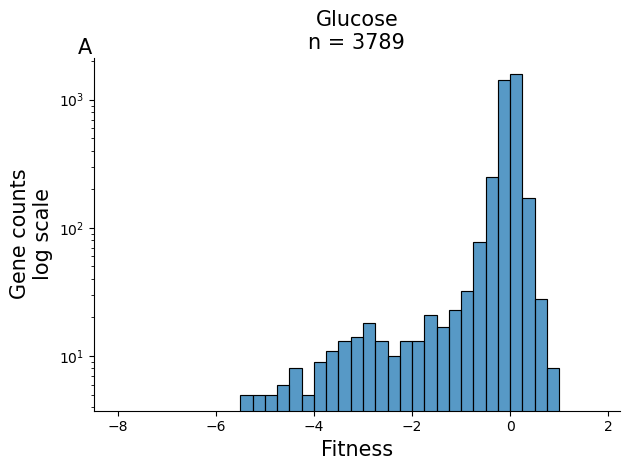

In [91]:
ax = plt.subplot(1, 1, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

sns.histplot(selected_fitness.Glucose,
             bins=[-8 + x * (1 / 4) for x in range(40)])

plt.xlabel('Fitness', fontsize=15)
plt.ylabel('Gene counts\nlog scale', fontsize=15)
plt.yscale('log')
n = selected_fitness.Glucose.shape[0]
plt.title(f'Glucose\nn = {n}', fontsize=15, ha='center')
plt.text(-8.8, 3000, 'A', fontsize=15, ha='left', va='top')

plt.tight_layout()

plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('../Output/Figure_01_Panel_A.svg')

### Figure 01 Panel B
### Assessing the distribution of protein mass values in a standard condition (Glucose minimal medium)

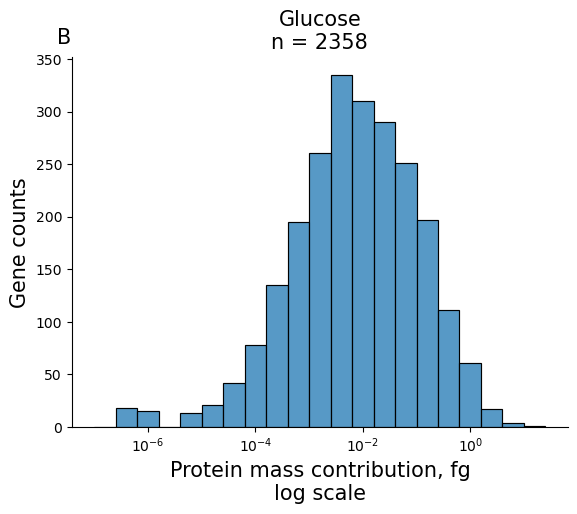

In [92]:
ax = plt.subplot(1,1,1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
sns.histplot(protein_mass.Glucose,
            bins = [0.0000001 * (10**(0.4*x)) for x in range(22)], # bin size is 0.5 orders of magnitude
            edgecolor="black", linewidth=0.85)
plt.xscale('log')
plt.xlabel('Protein mass contribution, fg\nlog scale', fontsize = 15)
plt.ylabel('Gene counts', fontsize = 15)
n = protein_mass.Glucose.shape[0]
plt.title(f'Glucose\nn = {n}', fontsize=15, ha='center')

plt.text(0.00000002, 380, 'B', fontsize=15, ha='left', va='top')

#plt.tight_layout()

plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('../Output/Figure_01_Panel_B.svg')

### Figure 01 Panels C-M
### Scatter plots of Fitness and protein mass

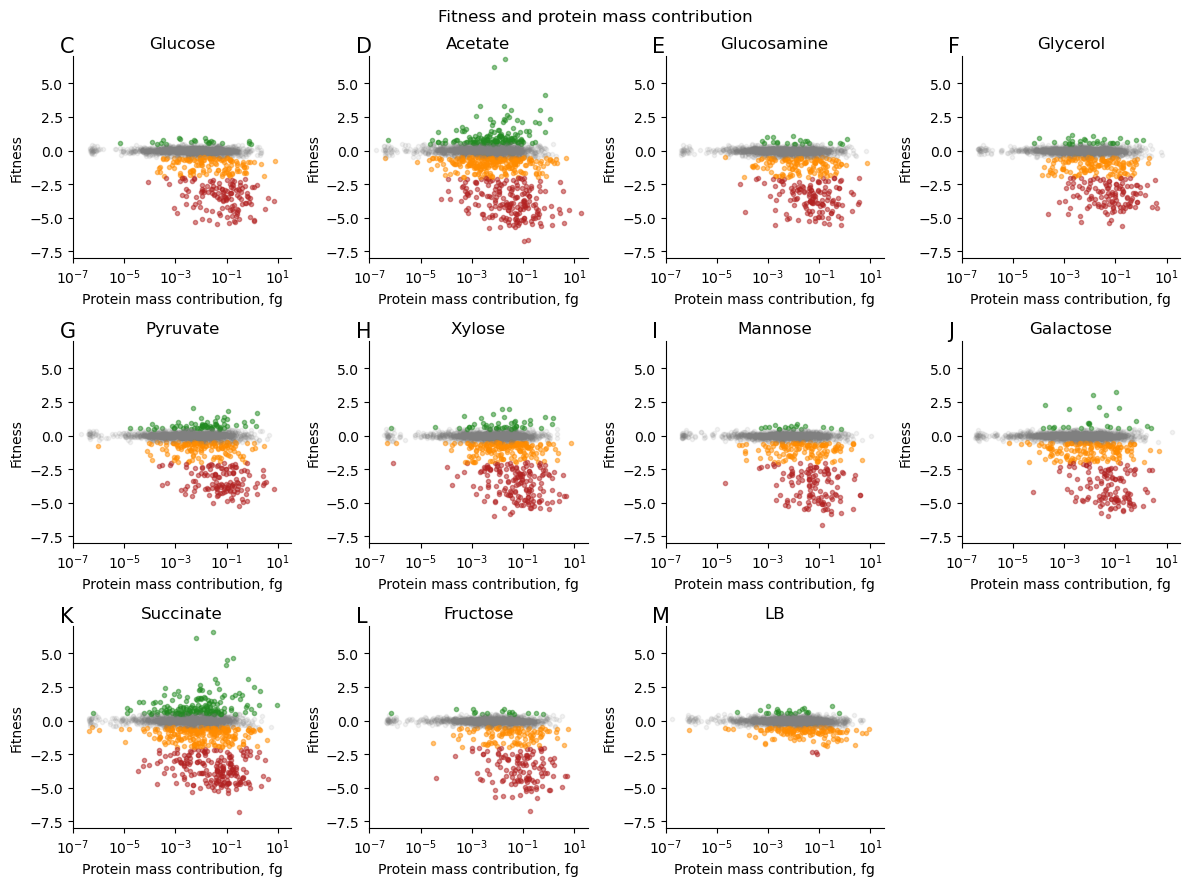

In [93]:
plt.figure(figsize=(12, 9))
plt.suptitle('Fitness and protein mass contribution')

for n, condition in enumerate(selected_fitness.columns[1:]):
    if condition in protein_mass.columns:
        ax = plt.subplot(3, 4, n + 1)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        plt.title(condition)
        
        for bnum in set(selected_fitness.index).intersection(set(protein_mass.Bnumber)):
            if protein_mass.loc[protein_mass.Bnumber == bnum][condition].values[0] > 0:
                if selected_fitness.loc[bnum][condition] > 0.5:
                    plt.plot(protein_mass.loc[protein_mass.Bnumber == bnum][condition].values[0],
                             selected_fitness.loc[bnum][condition],
                             color='forestgreen', alpha=0.5, linestyle='none', marker='.')
                elif selected_fitness.loc[bnum][condition] < -2:
                    plt.plot(protein_mass.loc[protein_mass.Bnumber == bnum][condition].values[0],
                             selected_fitness.loc[bnum][condition],
                             color='firebrick', alpha=0.5, linestyle='none', marker='.')
                elif selected_fitness.loc[bnum][condition] > -2 and selected_fitness.loc[bnum][condition] < -0.5:
                    plt.plot(protein_mass.loc[protein_mass.Bnumber == bnum][condition].values[0],
                             selected_fitness.loc[bnum][condition],
                             color='darkorange', alpha=0.5, linestyle='none', marker='.')
                else:
                    plt.plot(protein_mass.loc[protein_mass.Bnumber == bnum][condition].values[0],
                             selected_fitness.loc[bnum][condition],
                             color='gray', alpha=0.10, linestyle='none', marker='.')
        
        plt.xlim(0.0000001, 33)
        plt.ylim(-8, 7)
        plt.xscale('log')
        plt.xlabel('Protein mass contribution, fg')
        plt.ylabel('Fitness')
        
        plt.text(0.00000003, 8.5, chr(67 + n), fontsize=15, ha='left', va='top')

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('../Output/Figure_01_Panels_C_to_M.svg')

### Classifying genes into Fitness categories in all 46 conditions

In [94]:
# Dictionary to contain one data frame per condition. Each data frame will contain the classified genes
fitness_classified = {}

for column in fitness_averages.columns[1:]:
    fitness_classified[column] = pd.DataFrame()
    fitness_classified[column]['bnumber'] = fitness_averages.bnumber
    fitness_classified[column].index = fitness_classified[column]['bnumber']
    fitness_classified[column]['Fitness'] = fitness_averages[column]
    fitness_classification = []
    for gene in fitness_classified[column].index:
        if fitness_classified[column].loc[gene].Fitness <= -2:
            fitness_classification.append('essential')
        elif fitness_classified[column].loc[gene].Fitness >= -0.5 and fitness_classified[column].loc[gene].Fitness <= 0.5:
            fitness_classification.append('no_effect')
        elif fitness_classified[column].loc[gene].Fitness > -2 and fitness_classified[column].loc[gene].Fitness <-0.5:
            fitness_classification.append('important')
        elif fitness_classified[column].loc[gene].Fitness > 0.5:
            fitness_classification.append('fitness-enhancing')
        else:
            fitness_classification.append('huh')
    fitness_classified[column]['classification'] = fitness_classification

# Showing the data frame for glucose as example.
fitness_classified['set1IT003 D-Glucose (C)']

,bnumber,Fitness,classification
bnumber,,,
b4699,b4699,0.1550,no_effect
b4698,b4698,-0.0890,no_effect
b4701,b4701,-0.1760,no_effect
b4704,b4704,-0.0870,no_effect
b4702,b4702,-2.7585,essential
...,...,...,...
b4687,b4687,0.3605,no_effect
b4684,b4684,-0.0385,no_effect
b4685,b4685,-0.3170,no_effect


In [95]:
# Dictionary to contain data frames with fitness and proteomics data for each condition shared in both datasets
fg_and_F = {}

# Selecting shared conditions
for condition in list(set(protein_mass.columns).intersection(set(selected_fitness.columns)))[:]:
    df = pd.DataFrame()
    
    # Lists to contain values
    bnumbers = []
    fg = []
    Fitness = []
    fitness_classification = []
    
    # Selecting genes shared in both datasets
    for gene in set(protein_mass.Bnumber).intersection(set(selected_fitness.bnumber)):
        bnumbers.append(gene)
        fg.append(protein_mass.loc[protein_mass.Bnumber == gene][condition].values[0])
        Fitness.append(selected_fitness.loc[gene][condition])
        if selected_fitness.loc[gene][condition] <= -2:
            fitness_classification.append('essential')
        elif selected_fitness.loc[gene][condition] >= -0.5 and selected_fitness.loc[gene][condition] <= 0.5:
            fitness_classification.append('no_effect')
        elif selected_fitness.loc[gene][condition] > -2 and selected_fitness.loc[gene][condition] <-0.5:
            fitness_classification.append('important')
        elif selected_fitness.loc[gene][condition] > 0.5:
            fitness_classification.append('fitness-enhancing')
        else:
            fitness_classification.append('huh')
    
    # Creating the columns for each condition data frames
    df['bnumber'] = bnumbers
    df['fg'] = fg
    df['Fitness'] = Fitness
    df['classification'] = fitness_classification
    df['abs_fitness'] = [abs(f) for f in Fitness]
    
    # Adding the condition data frame to the containing dictionary
    fg_and_F[condition] = df

print('Conditions in the dictionary:', list(fg_and_F.keys()))
print('\nExample data frame:\n', df.head())

Conditions in the dictionary: ['Xylose', 'LB', 'Glycerol', 'Succinate', 'Galactose', 'Glucosamine', 'Mannose', 'Fructose', 'Acetate', 'Pyruvate', 'Glucose']

Example data frame:
   bnumber        fg  Fitness classification  abs_fitness
0   b1123  0.215403  -0.0125      no_effect       0.0125
1   b1127  0.019490   0.0800      no_effect       0.0800
2   b3590  0.005562   0.0825      no_effect       0.0825
3   b3386  0.021339  -2.2450      essential       2.2450
4   b3959  0.287850  -2.8525      essential       2.8525


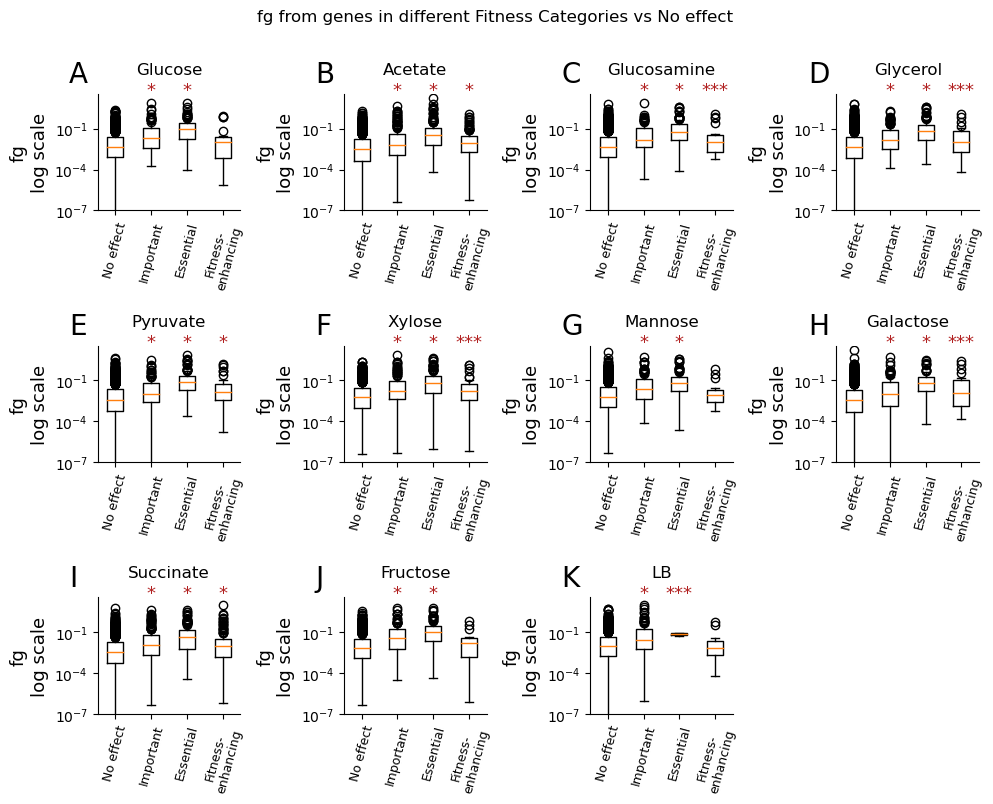

In [96]:
plt.figure(figsize=(10, 8))
plt.suptitle('fg from genes in different Fitness Categories vs No effect', y=1)

# Add letters to label the subplots
letters = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
labels = ['No effect', 'Important', 'Essential', 'Fitness-enhancing']

for n, condition in enumerate(list(selected_fitness.columns[1:])):
    ax = plt.subplot(3, 4, n + 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.title(condition, y=1.1)
    plt.yscale('log')

    data = [
        fg_and_F[condition].loc[fg_and_F[condition].classification == 'no_effect'].fg.dropna(),
        fg_and_F[condition].loc[fg_and_F[condition].classification == 'important'].fg.dropna(),
        fg_and_F[condition].loc[fg_and_F[condition].classification == 'essential'].fg.dropna(),
        fg_and_F[condition].loc[fg_and_F[condition].classification == 'fitness-enhancing'].fg.dropna()
    ]

    plt.boxplot(data)
    plt.ylabel('fg\nlog scale', fontsize=13)
    plt.yscale('log')

    plt.xticks([1, 2, 3, 4], ['No effect', 'Important', 'Essential', 'Fitness-\nenhancing'],
               fontsize=9, rotation=75)

    ax.text(-0.2, 1.1,
            letters[n],
            transform=ax.transAxes,
            size=20,
            # weight='bold'
           )

    # Perform Kruskal-Wallis tests to compare the "no effect" group with all others, individually
    for c in range(1, len(data)):
        statistic, p_value = kruskal(data[0], data[c])
        if p_value < 0.001:
            y = 15
            plt.text(c + 1, y, '*', ha='center', va='bottom', fontsize=13, color='firebrick')
            continue
        elif p_value < 0.01:
            y = 15
            plt.text(c + 1, y, '**', ha='center', va='bottom', fontsize=13, color='firebrick')
            continue
        elif p_value < 0.1:
            y = 15
            plt.text(c + 1, y, '***', ha='center', va='bottom', fontsize=13, color='firebrick')

    plt.ylim(0.0000001, 34)
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('../Output/Figure_S1_All_Panels.svg')
plt.savefig('../Output/Figure_S1_All_Panels.png')

### Enhancing only

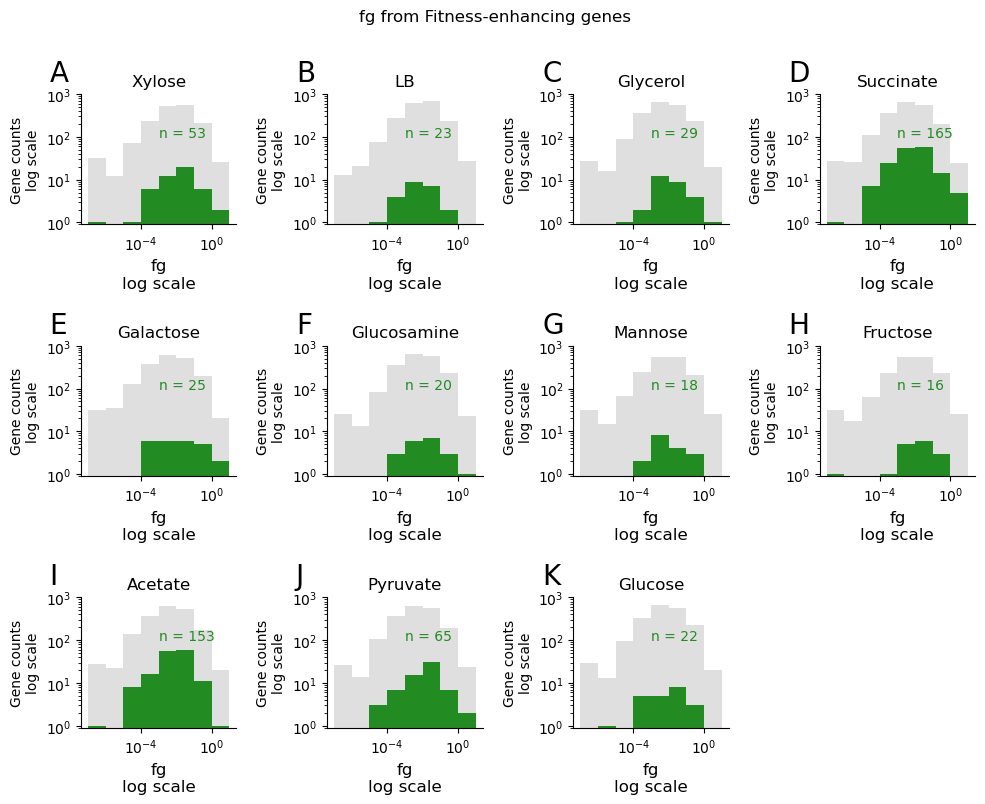

In [97]:
bins_ = [0.0000001, 0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10]
letters = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'

plt.figure(figsize = (10, 8))

plt.suptitle('fg from Fitness-enhancing genes', y = 1)

for n, condition in enumerate(list(fg_and_F.keys())):
    
    ax = plt.subplot(3, 4, n+1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.title(condition)
    ax.text(-0.2, 1.1,
            letters[n],
            transform=ax.transAxes,
            size=20,
           )
    
    plt.hist(fg_and_F[condition].fg, bins = bins_, color = 'gray', alpha = 0.25, label = 'Any Fitness');
    plt.hist(fg_and_F[condition].loc[fg_and_F[condition].classification == 'fitness-enhancing'].fg,
             bins = bins_, label = 'fitness > 0.5', color = 'forestgreen')
    plt.text(0.001, 100,
             'n = ' + str(len(fg_and_F[condition].loc[fg_and_F[condition].classification == 'fitness-enhancing'].fg)),
            color = 'forestgreen')
    plt.xscale('log')
    plt.xlabel('fg\nlog scale', fontsize = 12)
    plt.ylim(0.9, 1000)
    plt.ylabel('Gene counts\nlog scale')
    plt.yscale('log')

#     if condition == 'Glucose':
#         plt.legend(loc= (3.8, -2.4))
plt.tight_layout()

plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('../Output/Enhancing_fg_Histograms.svg')

In [98]:
print('genes in protein mass db', len(protein_mass.index))
print('genes in the fitness db', len(fitness_table.index))
print('overlap of protein and fitness', len(set(protein_mass.Bnumber) & set(fitness_table.sysName)))
print('protein db coverage', 1951/2358*100)
print('fitness db coverage', 1951/3789*100)

genes in protein mass db 2358
genes in the fitness db 3789
overlap of protein and fitness 1951
protein db coverage 82.73960983884649
fitness db coverage 51.49115861704935


In [99]:
len(fitness_table.index)

3789